In [12]:
import numpy as np
import pandas as pd

%matplotlib inline
import matplotlib.pyplot as plt

events = pd.read_csv("events.dat", sep=" ")
events["chirp_mass"] = (events["mass_1"] * events["mass_2"])**0.6 / (events["mass_1"] + events["mass_2"])**0.2
events["mass_ratio"] = events["mass_2"] / events["mass_1"]

events_wide = pd.read_csv("../wide_ETL/events.dat", sep=" ")

import corner

In [3]:
def quantile_list(key):
    quantiles = np.zeros(events.shape[0])
    for j in range(events.shape[0]):
    
        posterior = np.load(f"em_posteriors/source_{j}/posterior.npz")
    
        quantiles[j] = np.sum(posterior[key]<=events.loc[j, key]) / posterior[key].shape[0]

    return quantiles

def mass_quantiles(key):
    quantiles = np.zeros(events.shape[0])
    for j in range(events.shape[0]):
    
        posterior = np.load(f"gw_posteriors/source_{j}/posterior_mm.npz")
    
        quantiles[j] = np.sum(posterior[key]<=events.loc[j, key]) / posterior[key].shape[0]

    return quantiles

quantiles = quantile_list("log10_mej_wind")
quantiles_dyn = quantile_list('log10_mej_dyn')
quantiles_m1 = mass_quantiles("mass_1_source")
quantiles_m2 = mass_quantiles("mass_2_source")

(array([0.28235294, 1.12941176, 1.45882353, 1.12941176]),
 array([0.  , 0.25, 0.5 , 0.75, 1.  ]),
 [<matplotlib.patches.Polygon at 0x7ff428110e10>])

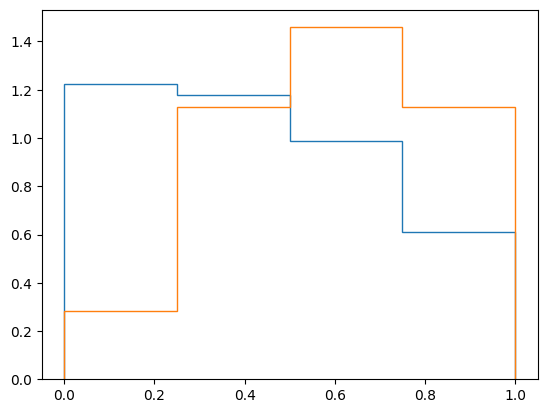

In [8]:

plt.hist(quantiles, histtype="step", density=True, bins=np.linspace(0, 1, 5))
plt.hist(quantiles_dyn, histtype="step", density=True, bins=np.linspace(0, 1, 5))


In [15]:

for j in range(85):
    posterior_mm = np.load(f"./gw_posteriors/source_{j}/posterior_mm.npz")
    print(np.corrcoef(posterior_mm["mass_2_source"], posterior_mm["theta_jn"])[0, 1])

0.012651344290533549
0.002159689324945829
0.0317174595112623
0.049226984026291234
-0.06816746888629609
0.024425354152253387
0.002440999498276437
0.007495537166043043
-0.005164716475424677
0.05761469164569464
0.03487299986211167
0.015009332508705241
-0.001489749907713787
0.02593954530474653
-0.023069108207089753
-0.035758757770940876
0.04772644195278638
0.03463433468416125
-0.01250742949693647
0.006645040196548632
0.003381856226268762
0.012700163091389117
-0.00284692662386684
0.03006930356127045
0.012502143309744276
0.012666832229501991
-0.010872256698460168
-0.040276886076916076
-0.004768451846502105
0.04760082455291085
-0.05885432364238818
-0.02880022555688409
0.01654158650411548
0.030766074365654802
0.02523105011873733
0.04260953744542942
-0.008640477736185613
-0.02180427860417066
-0.028445729879003883
-0.03211401496364852
-0.060769603046176804
0.017911013180663224
0.031786154053729664
0.01717808529635302
-0.005090002739678173
0.005319811315570335
-0.0021630077612312276
0.00991091836

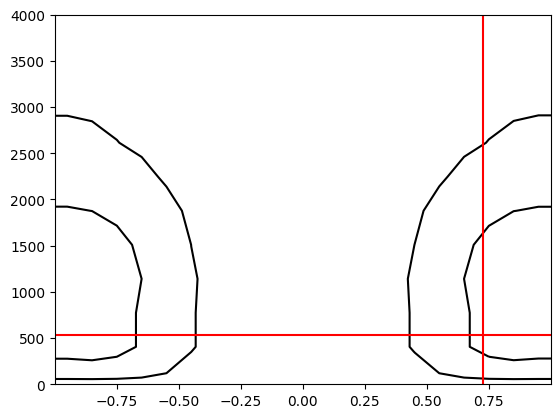

In [17]:
ind = 50
posterior = np.load(f"./em_posteriors/source_{ind}/posterior.npz")
corner.hist2d(posterior["cos_theta_jn"], posterior["luminosity_distance"], levels=[0.68, 0.95], plot_density=False, plot_datapoints=False, smooth=True)

plt.ylim((0, 4000))
plt.vlines([np.cos(events.loc[ind, "theta_jn"])], *plt.gca().get_ylim(), color="red")
plt.hlines([events.loc[ind, "luminosity_distance"]], *plt.gca().get_xlim(), color="red")


In [11]:
np.mean(posterior["luminosity_distance"]<=events.loc[64, "luminosity_distance"])

np.float64(0.21460987654320987)

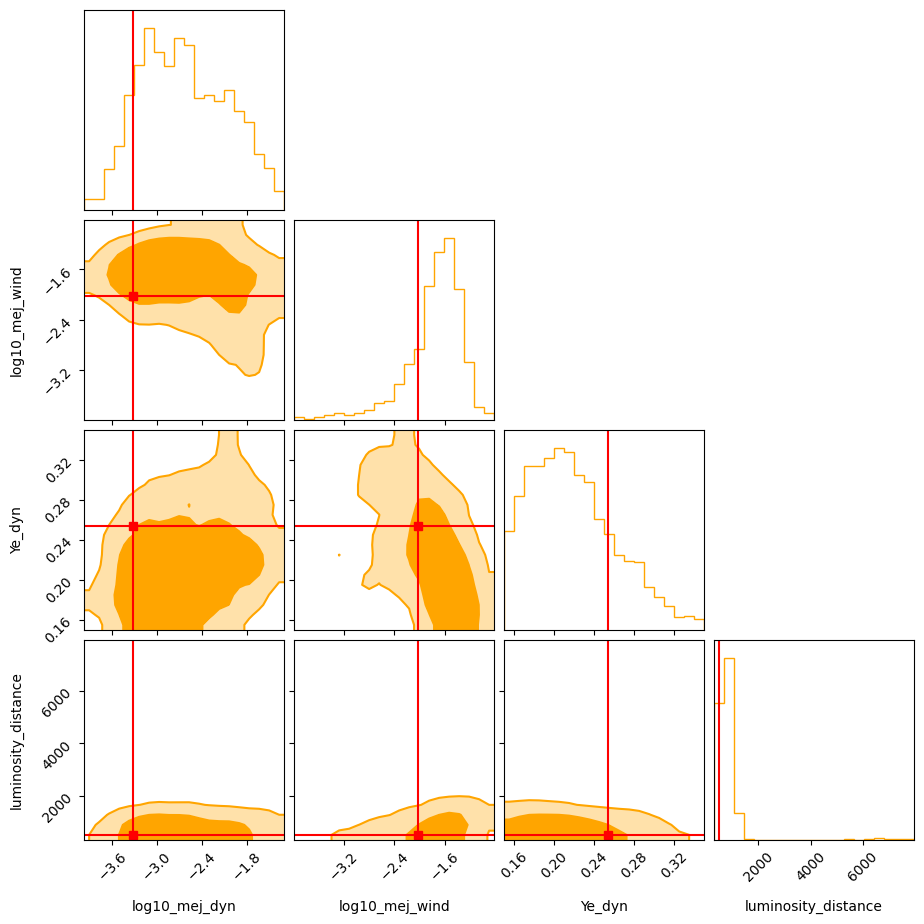

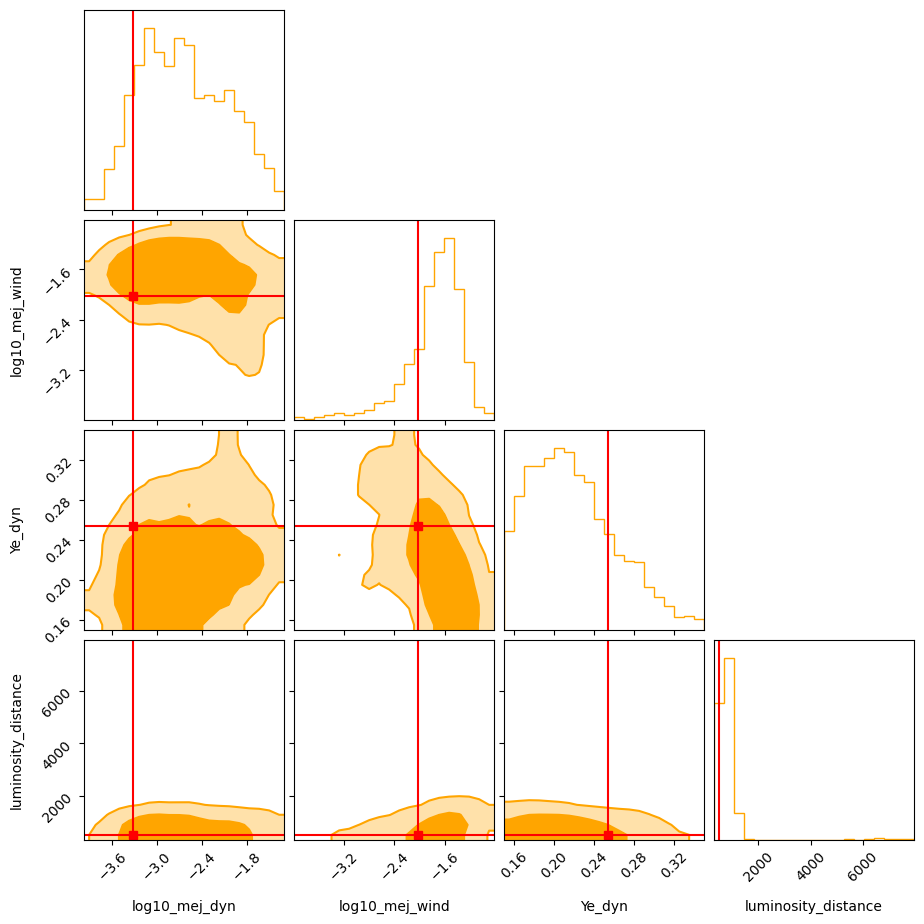

In [3]:
ind = 37
posterior_mm = pd.DataFrame(dict(np.load(f"./em_posteriors/source_{ind}/posterior.npz")))


corner.corner(posterior_mm[["log10_mej_dyn", "log10_mej_wind", "Ye_dyn", "luminosity_distance"]],
              color="orange", plot_datapoints=False, plot_density=False, fill_contours=True, smooth=True, levels=[0.68, 0.95],
              truths=events.loc[ind].to_dict(),truth_color="red")

In [7]:
events.loc[37, "luminosity_distance"]

np.float64(517.7773769635838)